# Fashion MNIST - Code is the ultimate source of truth

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
df = pd.read_csv("fashion-mnist_train.csv")

In [3]:
df.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [4]:
df.tail(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59990,0,0,0,0,0,0,0,0,0,0,...,154,161,165,83,0,5,0,0,0,0
59991,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59992,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59993,2,0,0,0,0,0,0,1,0,0,...,0,0,0,0,141,113,9,0,0,0
59994,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info

<bound method DataFrame.info of        label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0          2       0       0       0       0       0       0       0       0   
1          9       0       0       0       0       0       0       0       0   
2          6       0       0       0       0       0       0       0       5   
3          0       0       0       0       1       2       0       0       0   
4          3       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
59995      9       0       0       0       0       0       0       0       0   
59996      1       0       0       0       0       0       0       0       0   
59997      8       0       0       0       0       0       0       0       0   
59998      8       0       0       0       0       0       0       0       0   
59999      7       0       0       0       0       0       0       0       0   

       

### Splitting data into train/dev and normalizing pixel values of 255

In [6]:
m,n = df.shape
index = int(0.8*m)
data = df.to_numpy()
train_data = data[:index]
dev_data = data[index:]

In [7]:
train_data = train_data.T
Y_train = train_data[0]
X_train = train_data[1:]
X_train = X_train/255

In [8]:
dev_data = dev_data.T
Y_dev = dev_data[0]
X_dev = dev_data[1:]
X_dev = X_dev/255

##### Verifying the matrices

In [9]:
Y_train

array([2, 9, 6, ..., 6, 1, 7])

In [10]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [11]:
Y_dev

array([7, 7, 1, ..., 8, 8, 7])

In [12]:
X_dev

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Initializing Parameters ( 784 -> 64 -> 32 -> 16 -> 10)

In [13]:
def init_params():
    W1 = np.random.rand(64,784) - 0.5
    b1 = np.random.rand(64,1) - 0.5
    W2 = np.random.rand(32,64) - 0.5
    b2 = np.random.rand(32,1) - 0.5
    W3 = np.random.rand(16,32) - 0.5
    b3 = np.random.rand(16,1) - 0.5
    W4 = np.random.rand(10,16) - 0.5
    b4 = np.random.rand(10,1) - 0.5
    
    return W1,b1,W2,b2,W3,b3,W4,b4

In [14]:
init_params()

(array([[-0.01783012, -0.36967503, -0.49914507, ..., -0.32759193,
         -0.1923932 , -0.38076265],
        [ 0.15416212,  0.38349949,  0.37734284, ...,  0.27694622,
          0.10731227,  0.29473365],
        [ 0.35463445,  0.36110746,  0.16238474, ...,  0.10893148,
         -0.29347722,  0.04539031],
        ...,
        [-0.36697664, -0.18191796,  0.0391041 , ..., -0.47548516,
          0.02388765, -0.41192341],
        [-0.33369022, -0.25425093, -0.40592209, ...,  0.40398985,
         -0.28479019, -0.14423593],
        [-0.03089896, -0.33715375, -0.1679921 , ...,  0.08956847,
          0.47329853, -0.35396915]]),
 array([[-0.09181584],
        [-0.36816119],
        [-0.27385359],
        [-0.21200609],
        [ 0.30813475],
        [-0.0243135 ],
        [ 0.45710643],
        [ 0.18271032],
        [-0.23239943],
        [ 0.34430565],
        [ 0.38668788],
        [ 0.38386581],
        [-0.20894451],
        [ 0.0780859 ],
        [ 0.45991482],
        [ 0.37438136],
     

### Utility Fucntions

In [15]:
def ReLU(Z):
    return np.maximum(Z,0)

def derivative_ReLU(Z):
    return Z>0

def softmax(Z):
    expZ = np.exp(Z-np.max(Z,axis = 0,keepdims = True))
    return expZ/np.sum(expZ, axis = 0, keepdims = True)

def one_hot(Y):
    size = Y.size
    one_hot_Y = np.zeros((10,size))
    for index,val in enumerate(Y):
        one_hot_Y[val][index] = 1
    return one_hot_Y

In [16]:
one_hot(Y_train)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

## Main Functions

In [17]:
def forward_pass(X,W1,b1,W2,b2,W3,b3,W4,b4):
    
    #X is 784 x 1, W1 is 64 x 784 -> 64x1
    Z1 = W1.dot(X) + b1
    
    A1 = ReLU(Z1)
    
    #W2 is 32 x 64, A1 is 64 x 1 -> 32 x 1
    Z2 = W2.dot(A1) + b2
    
    A2 = ReLU(Z2)
    
    #W3 is 16 x 32, A2 is 32 x 1 -> 16 x 1
    Z3 = W3.dot(A2) + b3
    
    A3 = ReLU(Z3)
    
    #W4 is 10 x 16, A3 is 16 x 1 -> 10 x 1
    Z4 = W4.dot(A3) + b4
    
    A4 = softmax(Z4)
    
    return Z1,A1,Z2,A2,Z3,A3,Z4,A4

In [18]:
def backward_pass(X,Y,Z1,A1,Z2,A2,Z3,A3,Z4,A4,W1,W2,W3,W4):
    
    m = Y.size
    
    one_hot_Y = one_hot(Y)
    
    #Using Categorical Cross Entropy Loss with SoftMax
    dZ4 = A4 - one_hot_Y
    
    #dZ4 is the global gradient -> 10 x m -> per training example -> 10 x 1
    #Local grad is just xi in ∑xi*wi , so A3 is 16 x 1 -> So Transpose(A3) = 1 x 16
    #dZ4 x A3.T = (10x1) * (1x16) -> (10x16)
    dW4 = 1/m * dZ4.dot(A3.T)
    
    #Local grad is just 1
    db4 = 1/m * np.sum(dZ4,axis = 1,keepdims = True)
    
    #W3 is local grad -> 10 x 16 -> So transpose as 16 x 10 needed
    #dZ4 is global grad -> 10 x m
    #W3.T * dZ4 = (16x10) * (10xm) -> (16 x m)
    #Now we can just remove activation function
    dZ3 = W4.T.dot(dZ4) * derivative_ReLU(Z3)
    
    #dZ3 is 16 x m -> 16 x 1
    #A2 is 32 x 1
    dW3 = 1/m * dZ3.dot(A2.T)
    
    db3 = 1/m * np.sum(dZ3,axis = 1,keepdims = True)
    
    #Similarly,
    dZ2 = W3.T.dot(dZ3) * derivative_ReLU(Z2)
    
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1/m * np.sum(dZ2, axis = 1, keepdims = True)
    
    #Similarly,
    dZ1 = W2.T.dot(dZ2) * derivative_ReLU(Z1)
    
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1,axis = 1,keepdims = True)
    
    return dW1,db1,dW2,db2,dW3,db3,dW4,db4

In [19]:
def update_params(alpha,W1,b1,W2,b2,W3,b3,W4,b4,dW1,db1,dW2,db2,dW3,db3,dW4,db4):
    
    W1 -= alpha * dW1
    b1 -= alpha * db1
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W3 -= alpha * dW3
    b3 -= alpha * db3
    W4 -= alpha * dW4
    b4 -= alpha * db4
    
    return W1,b1,W2,b2,W3,b3,W4,b4

### Driver Function

In [20]:
def get_prediction(A):
    return np.argmax(A,0)

def get_accuracy(predictions,Y):
    return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,epochs):
    
    #Doing mini batches
    batch_size = 100
    
    W1,b1,W2,b2,W3,b3,W4,b4 = init_params()
    
    for i in range(epochs):
        
        for start in range(0,Y.size,batch_size):
            
            end = start + batch_size
            
            if start==end: break
            
            X_batch = X[:, start:end]
            Y_batch = Y[start:end]
        
            Z1,A1,Z2,A2,Z3,A3,Z4,A4 = forward_pass(X_batch,W1,b1,W2,b2,W3,b3,W4,b4)

            dW1,db1,dW2,db2,dW3,db3,dW4,db4 = backward_pass(X_batch,Y_batch,Z1,A1,Z2,A2,Z3,A3,Z4,A4,W1,W2,W3,W4)

            W1,b1,W2,b2,W3,b3,W4,b4 = update_params(alpha,W1,b1,W2,b2,W3,b3,W4,b4,dW1,db1,dW2,db2,dW3,db3,dW4,db4)
        
        #Print every 20th epoch
        if i%10==0:
            
            _,_,_,_,_,_,_,A = forward_pass(X,W1,b1,W2,b2,W3,b3,W4,b4)
            
            print("epoch : ",i)
            predicitions = get_prediction(A)
            print(get_accuracy(predicitions,Y))
            
    return W1,b1,W2,b2,W3,b3,W4,b4

In [21]:
W1,b1,W2,b2,W3,b3,W4,b4 = gradient_descent(X_train,Y_train,0.1,200)

epoch :  0
0.6992916666666666
epoch :  10
0.8541875
epoch :  20
0.8719375
epoch :  30
0.883875
epoch :  40
0.8943541666666667
epoch :  50
0.9011666666666667
epoch :  60
0.9097291666666667
epoch :  70
0.909625
epoch :  80
0.9153958333333333
epoch :  90
0.9136041666666667
epoch :  100
0.921625
epoch :  110
0.9204166666666667
epoch :  120
0.9185416666666667
epoch :  130
0.920375
epoch :  140
0.9216666666666666
epoch :  150
0.9256875
epoch :  160
0.9240833333333334
epoch :  170
0.9308958333333334
epoch :  180
0.9325208333333334
epoch :  190
0.9305625


### Testing prediction on Dev Set

In [22]:
def make_predictions(X,W1,b1,W2,b2,W3,b3,W4,b4):
    
    _, _, _, _, _, _, _, A = forward_pass(X,W1,b1,W2,b2,W3,b3,W4,b4)
    
    predictions = get_prediction(A)
    
    return predictions

In [24]:
predictions = make_predictions(X_dev,W1,b1,W2,b2,W3,b3,W4,b4)
get_accuracy(predictions,Y_dev)

0.8549166666666667

### Visualizing the results

In [25]:
fashion_labels = {
    0: "T-shirt/Top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot"
}

In [26]:
def test_prediction(index, W1, b1, W2, b2, W3, b3, W4, b4):

    currImg = X_train[:, index, None]

    prediction = make_predictions(
        currImg,
        W1, b1,
        W2, b2,
        W3, b3,
        W4, b4
    )[0]

    label = Y_train[index]

    print(f"Prediction: {fashion_labels[prediction]}")
    print(f"Actual: {fashion_labels[label]}")

    current_image = currImg.reshape((28, 28)) * 255

    plt.imshow(current_image, cmap='gray')
    plt.title(
        f"Predicted: {fashion_labels[prediction]}\n"
        f"Actual: {fashion_labels[label]}"
    )
    plt.axis("off")
    plt.show()

Prediction: Shirt
Actual: Pullover


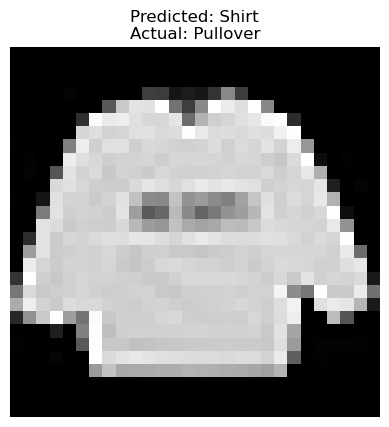

Prediction: Ankle Boot
Actual: Ankle Boot


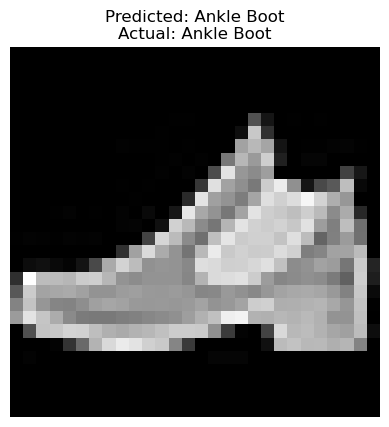

Prediction: Shirt
Actual: Shirt


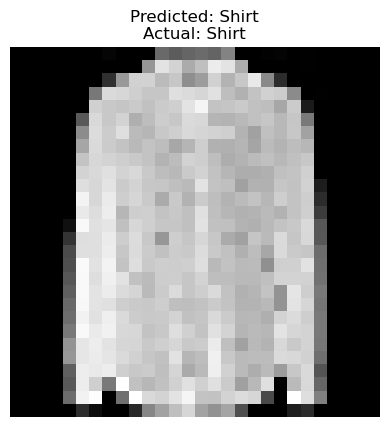

Prediction: T-shirt/Top
Actual: T-shirt/Top


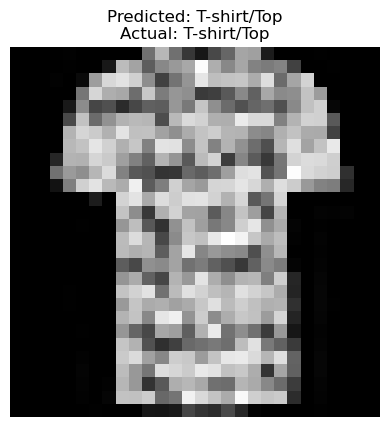

In [27]:
test_prediction(0, W1, b1, W2, b2,W3,b3,W4,b4)
test_prediction(1, W1, b1, W2, b2,W3,b3,W4,b4)
test_prediction(2, W1, b1, W2, b2,W3,b3,W4,b4)
test_prediction(3, W1, b1, W2, b2,W3,b3,W4,b4)